In [18]:
import kagglehub
import numpy as np
from torch import nn
import matplotlib.pyplot as plt 
import pandas as pd
import os
from pathlib import Path
from torch.utils.data import DataLoader, Dataset, random_split, Subset
import torchvision.io as io
from torchvision import transforms, utils
import torch

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [39]:

dir = "./data"

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset", output_dir=dir + "/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database", output_dir=dir+"/covid19-radiography-database")
print("Path to dataset files:", path)

100%|██████████| 157M/157M [00:07<00:00, 23.1MB/s] 

Extracting files...


Path to dataset files: ./data/brain-tumor-mri-dataset


100%|██████████| 778M/778M [00:52<00:00, 15.7MB/s] 

Extracting files...


Path to dataset files: ./data/covid19-radiography-database


In [51]:
class scans_dataset(Dataset):
    def __init__(self, *, dataset):
        self.df = self.build_dataframe(dataset)
        self.length = self.df.shape[0]

    def __getitem__(self, index):
        item = self.df.iloc[index]
        scan = io.read_image(item['scan'])
        return scan, item['class']
    
    def __len__(self):
        return self.df.shape[0]
        
    
        
    def build_dataframe(self, dataset="covid"):
        df = pd.DataFrame()
        if dataset == "tumors":
            classes = {"glioma":1, "meningioma":2, "notumor": 3, "pituitary":4}
            path = "data/brain-tumor-mri-dataset"
            for t in ["Training", "Testing"]:
                for f in [d for d in os.listdir(path + "/" + t) if os.path.isdir(path + "/" + t + "/" + d)]:
                    files = [d for d in os.listdir(path + f'/{t}/{f}')]
                    label = Path(f).name
                    df = pd.concat([df, pd.DataFrame({'testing': t=="Testing", 'label': label, 'class': classes[label], 'scan': files})], ignore_index=True)
        elif dataset == "covid":
            classes = {"COVID": 1, "Lung_Opacity":2, "Normal":3, "Viral Pneumonia":4}
            path = "data/covid19-radiography-database/COVID-19_Radiography_Dataset"
            for f in [d for d in os.listdir(path) if os.path.isdir(path+ "/"+ d)]:
                images = [f'{path}/{f}/images/{d}' for d in os.listdir(path + f'/{f}/images')]
                masks = [f'{path}/{f}/masks/{d}' for d in os.listdir(path+f'/{f}/masks')]
                label = Path(f).name
                df = pd.concat([df, pd.DataFrame({'label': label, 'class': classes[label], 'scan': images, 'mask': masks})], ignore_index=True)
        else:
            raise ValueError("No such dataset")
        
        return df
            

In [52]:
data = scans_dataset(dataset="covid")
scan, label = data.__getitem__(100)
transform = transforms.CenterCrop(size=(256,256))
scan = transform(scan)
scan.size()

torch.Size([1, 256, 256])

In [6]:
class ResidualLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualLayer, self).__init__()

        self.down_scale_flag = in_channels != out_channels
        self.mish = nn.Mish()

        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels = out_channels,
            kernel_size=(3,3),
            padding='same'
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv_2 = nn.Conv2d(
            in_channels=in_channels,
            out_channels = out_channels,
            kernel_size=(3,3),
            padding='same'
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.down_scale = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=(3,3),
                padding='same',
                
            ),
            nn.BatchNorm2d(out_channels)
        )

        
    def forward(self, x):
        identity = self.down_scale(x) if self.down_scale_flag else x
        x = self.conv(x)
        x = self.bn1(x)
        x = self.mish(x)
        x = self.conv_2(x)
        x = self.bn2(x)
        x = self.mish(x + identity)
        return x
        

In [7]:
class scan_cnn(nn.Module):
    def __init__(self, n_classes, input_channels, image_size: tuple, n_layers = 1):
        super(scan_cnn, self).__init__()
        self.layers = n_layers
        self.conv_block = nn.Conv2d(in_channels=input_channels,
                                    out_channels=16,
                                    kernel_size=(3,3),
                                    padding='same')
        self.mish = nn.Mish()
        self.norm = nn.BatchNorm2d(16)
        self.residual_block_1 = nn.Sequential(
            ResidualLayer(16,16),
            ResidualLayer(16,16),
            ResidualLayer(16,16),
            nn.AvgPool2d(kernel_size=(2,2), stride=(2,2))
        )
        # self.residual_block_2 = nn.Sequential(
        #     ResidualLayer(16, 32),
        #     ResidualLayer(32, 32),
        #     ResidualLayer(32, 32),
        #     nn.AvgPool2d(kernel_size=(2,2), stride=(2,2))
        # )
        # self.residual_block_3 = nn.Sequential(
        #     ResidualLayer(32, 64),
        #     ResidualLayer(64, 64),
        #     ResidualLayer(64, 64),
        #     nn.AvgPool2d((2,2), (2,2))
        # )
        # self.residual_block_4 = nn.Sequential(
        #     ResidualLayer(64, 128),
        #     ResidualLayer(128, 128),
        #     ResidualLayer(128, 128),
        #     nn.AvgPool2d(kernel_size=(2,2), stride=(2,2))
        # )

        self.flatten = nn.Flatten(1)
        in_features = image_size[0] // 2**1 * image_size[1] // 2**1 * 16
        
        self.linear = nn.Linear(
            in_features = in_features,
            out_features = n_classes
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.norm(x)
        x = self.mish(x)

        x = self.residual_block_1(x)

        x = self.flatten(x)
        x = self.linear(x)

        return x

In [45]:
def train(dataset, image_model, num_epochs):

    sum_loss = 0
    losses = []
    i = 0
    optimizer = torch.optim.Adam(image_model.parameters(), lr=.1)
    loss_fn = torch.nn.NLLLoss()
    log_softmax = nn.LogSoftmax(dim=0)
    crop = transforms.CenterCrop(size=(256,256))
    

    for epoch in range(num_epochs):
        for (X, y) in dataset:
            X = crop(X)
            X = X.float()
            X, Y = X.to(device), y.to(device)
            optimizer.zero_grad()

            output = image_model(X)
            output = log_softmax(output)
            loss = loss_fn(output, Y.long())

            loss.backward()
            optimizer.step()
            sum_loss += loss.item()
            losses.append(loss.item())
            i += 1
    return losses

        

In [54]:
dataset = scans_dataset(dataset="covid")
dataset = Subset(dataset, list(range(0,30)))
dataset = DataLoader(dataset, batch_size=2)
image_model = scan_cnn(n_classes=4, input_channels=1, image_size=(256,256))
losses = train(dataset, image_model, 10)


Text(0, 0.5, 'Log Loss')

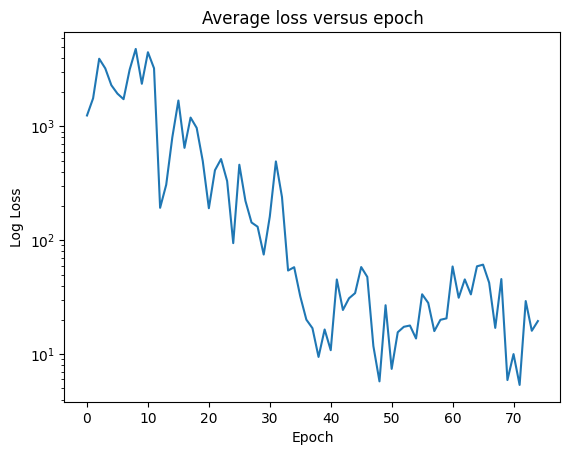

In [58]:

avg_loss = []
for i in range(0,len(losses), 2):
    avg_loss.append((losses[i]+losses[i+1])/2)

plt.semilogy(list(range(0,len(avg_loss))), avg_loss)
plt.title("Average loss versus epoch")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")